# E2E LGBM-only Baseline

**1 Trial = 전처리 → 집계 → CLF → FS → REG → RMSE (모두 Optuna)**

- 전처리(cleaning/outlier/agg preset) + CLF HP + REG HP + FS top_k 전부 단일 Optuna study에서 동시 탐색
- CLF·REG 모두 LightGBM 고정 (앙상블 없음)
- 같은 전처리 파라미터 조합은 LRU 캐시로 재사용
- 기존 `pipeline_config` 스위치 및 실험 로깅 구조는 그대로 유지

## 1. 환경 설정 및 데이터 로드

In [1]:
# ============================================================
# 환경 설정 + 데이터 로드 (Colab / Local 공통)
# ============================================================
import os, sys

try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    if not os.path.exists('/content/project/setup.py'):
        os.system('pip install -q gdown')
        os.system('gdown 1AD4PDBnDVjp-LSna6puB7qLnpBqB7j_I -O /content/code.zip')
        os.system('unzip -qo /content/code.zip -d /content/project')
        os.makedirs('/content/project/0_data', exist_ok=True)
        os.system('gdown 1yOUo0_wPLcuZBSJIK592b00YkSIlk4zO -O /content/project/0_data/dataset.zip')
        os.system('unzip -qo /content/project/0_data/dataset.zip -d /content/project/0_data')
        os.remove('/content/project/0_data/dataset.zip')
    if not os.path.exists('/content/project/2_preprocessing/cleaning.py'):
        os.system('gdown 1Rh0ByOS4Gama8XHuvY7KkOHo278H9YLr -O /content/preprocessing.zip')
        os.system('unzip -qo /content/preprocessing.zip -d /content/project')
    if not os.path.exists('/content/project/3_modeling/modules/e2e_hpo.py'):
        os.system('gdown 1Vrn5LBl611rWbag7d09LZH68_lfpu6wP -O /content/modules.zip')
        os.makedirs('/content/project/3_modeling/modules', exist_ok=True)
        os.system('unzip -qo /content/modules.zip -d /content/project/3_modeling/modules')
    sys.path.insert(0, '/content/project')
    %run /content/project/setup.py
except ImportError:
    %run ../setup.py

# --- 기본 라이브러리 ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# --- 프로젝트 유틸 ---
from utils.config import PROJECT_ROOT, SEED, TARGET_COL, KEY_COL, POSITION_COL, OUTPUT_DIR
from utils.data import load_all, get_feat_cols, split_xs
from utils.evaluate import evaluate, rmse, postprocess
from utils.experiment import (
    log_experiment, check_exp_id, check_duplicate_params, download_from_drive,
)

# --- 3_modeling 모듈 ---
sys.path.insert(0, os.path.join(PROJECT_ROOT, '3_modeling'))
from modules.e2e_hpo import (
    run_e2e_optimization_with_pp,
    rerun_best_trial_with_pp,
)
from modules.search_space import (
    PP_CLEAN_CANDIDATES,
    PP_OUTLIER_CANDIDATES,
    AGG_PRESETS,
)

# --- 데이터 로드 ---
xs, ys = load_all()
feat_cols = get_feat_cols(xs)
xs_dict = split_xs(xs)

print(f'Feature 수: {len(feat_cols)}')
print(f'Die 수: train={len(xs_dict["train"]):,}, '
      f'val={len(xs_dict["validation"]):,}, '
      f'test={len(xs_dict["test"]):,}')

setup 완료
Xs: (174980, 1091)  |  Ys: train=26,247, val=8,749, test=8,749
Feature 수: 1087
Die 수: train=104,988, val=34,996, test=34,996


## 2. 실험 설정

모든 파라미터는 이 셀에서만 제어한다.
전처리 + CLF HP + REG HP + FS top_k 전부 Optuna가 한번에 탐색한다.

In [2]:
# ============================================================
# 실험 설정
# ============================================================

EXP_ID = '3-3-005'
EXP_TYPE = 'baseline + HPO'
EXP_MEMO = 'lgbm-only, preprocessing+hp joint optuna'

# ── Test 평가 스위치 (test peeking 방지) ──
# True : 최종 제출 직전에만 권장 — test RMSE 계산·출력·로그
# False: test 예측 CSV는 저장하되 RMSE 계산·로그는 생략
EVAL_TEST = True

# ── 결과물 저장 스위치 ──
# True : val/test 예측 CSV + Optuna study pickle 저장
# False: 파일 저장 생략 (실험 로그는 SAVE_OUTPUTS와 무관하게 항상 기록)
SAVE_OUTPUTS = False

# --- Google Drive 파일 ID (실험 로그) ---
XLSX_GDRIVE_ID = '1IgaNh7ixgqpmH5PiwmSFbK2li6GODdew'
JSON_GDRIVE_ID = '1ycr6n5Ty_jzl4F-qQE4Cv5nS2WbIAZih'

LABEL_COL = 'label_bin'

# --- 샘플링 (빠른 sanity check용) ---
sampling_params = dict(
    use_sampling=False,
    sample_frac=1.0,
)

# --- 웨이퍼맵 기반 사전 제외 feature ---
EXCLUDE_COLS = [
    # 예: 'X123', 'X456', ...
]

# ── 파이프라인 스위치 (pipeline_config) ──
# 기존 e2e_twostage와 동일 구조.
# 단, input_level='die' 고정 (전처리부터 돌리므로 die 필수)
pipeline_config = dict(
    input_level='die',      # 'die' 고정 (분류on일 시 변경 불가)
    run_clf=True,           # False → 분류 스킵, 회귀만
    clf_output='proba',     # 'proba' | 'binary'
    clf_filter=False,       # True → 0 예측 샘플을 회귀에서 제외
    clf_optuna=True,        # False → CLF 기본 파라미터 (탐색 제외)
    run_fs=False,           # False → FS 스킵
    fs_optuna=False,        # False → 고정 top_k
    reg_level='position',   # 'unit' | 'position'
    reg_optuna=True,        # False → REG 기본 파라미터 (탐색 제외)
)

# ── E2E HPO 설정 ──
# clf_model/reg_model는 'lgbm' 고정 (baseline)
e2e_params = dict(
    clf_model='lgbm',
    reg_model='lgbm',
    n_trials=1,
    n_folds=3,
    clf_early_stop=50,
    reg_early_stop=50,
    imbalance_method='scale_pos_weight',
    top_k_range=(50, 500),  # fs_optuna=True 일 때 탐색 범위
    top_k_fixed=200,        # fs_optuna=False 일 때 고정 값
    clf_fixed={},           # CLF 고정 파라미터 (탐색 제외)
    reg_fixed={},           # REG 고정 파라미터 (예: {'objective': 'poisson'})
    pp_cache_size=10,       # 전처리 LRU 캐시 상한
)

# ── Rerun 설정 (best trial 재실행) ──
rerun_params = dict(
    mode='kfold',            # 'single' | 'kfold'
    n_folds=5,               # mode='kfold'일 때만 사용
    es_holdout=0.1,          # mode='single'일 때 ES용 holdout 비율
    clf_early_stop=100,
    reg_early_stop=100,
)

# --- 설정 출력 ---
print(f'실험번호: {EXP_ID} | {EXP_TYPE}')
print(f'CLF: {e2e_params["clf_model"]} | REG: {e2e_params["reg_model"]}')
print(f'Trials: {e2e_params["n_trials"]} | Folds: {e2e_params["n_folds"]}')
print(f'Top-K: range={e2e_params["top_k_range"]}, fixed={e2e_params["top_k_fixed"]}')
print(f'PP cache size: {e2e_params["pp_cache_size"]}')
print(f'샘플링: {"ON" if sampling_params["use_sampling"] else "OFF"} '
      f'(frac={sampling_params["sample_frac"]})')
print(f'Rerun: mode={rerun_params["mode"]}'
      + (f', n_folds={rerun_params["n_folds"]}' if rerun_params["mode"] == "kfold"
         else f', es_holdout={rerun_params["es_holdout"]}'))
print(f'제외 컬럼: {len(EXCLUDE_COLS)}개')
print(f'결과 저장: {"ON" if SAVE_OUTPUTS else "OFF"} (CSV + study pickle)')
print(f'\n── Pipeline Config ──')
for k, v in pipeline_config.items():
    print(f'  {k}: {v}')

download_from_drive(XLSX_GDRIVE_ID, JSON_GDRIVE_ID)
check_exp_id(EXP_ID)

실험번호: 3-3-005 | E2E LGBM Baseline (pp+hp joint HPO)
CLF: lgbm | REG: lgbm
Trials: 1 | Folds: 3
Top-K: range=(50, 500), fixed=200
PP cache size: 10
샘플링: OFF (frac=1.0)
Rerun: mode=kfold, n_folds=5
제외 컬럼: 0개
결과 저장: OFF (CSV + study pickle)

── Pipeline Config ──
  input_level: die
  run_clf: True
  clf_output: proba
  clf_filter: False
  clf_optuna: True
  run_fs: False
  fs_optuna: False
  reg_level: position
  reg_optuna: True


## 3. 전처리 Search Space 확인 / 축소

`PP_CLEAN_CANDIDATES` / `PP_OUTLIER_CANDIDATES` / `AGG_PRESETS`는 `search_space.py`의 모듈 상수다.
아래 셀에서 dict/list 원소를 지우거나 수정하여 탐색 공간을 좁힐 수 있다.

**범위 조정 예시 (주석 해제해서 사용):**
```python
PP_CLEAN_CANDIDATES['imputation_method'] = ['median']       # spatial/knn 제외
PP_CLEAN_CANDIDATES['corr_threshold'] = [0.95]              # 상관 임계값 고정
PP_OUTLIER_CANDIDATES['method'] = ['winsorize', 'none']     # grubbs/lot_local 제외
```

In [3]:
# ── 현재 전처리 search space 확인 ──
print('── PP_CLEAN_CANDIDATES ──')
for k, v in PP_CLEAN_CANDIDATES.items():
    print(f'  {k}: {v}')
print('\n── PP_OUTLIER_CANDIDATES ──')
for k, v in PP_OUTLIER_CANDIDATES.items():
    print(f'  {k}: {v}')
print('\n── AGG_PRESETS ──')
for i, preset in enumerate(AGG_PRESETS):
    print(f'  [{i}] {preset}')

# ── 범위 축소 (필요 시 여기서 수정) ──
# PP_CLEAN_CANDIDATES['imputation_method'] = ['median']
# PP_CLEAN_CANDIDATES['corr_threshold'] = [0.95]
# PP_OUTLIER_CANDIDATES['method'] = ['winsorize', 'none']

# ── 탐색 공간 크기 추정 (grid 전개 시) ──
from functools import reduce
import operator
space_sizes = (
    [len(v) for v in PP_CLEAN_CANDIDATES.values()]
    + [len(v) for v in PP_OUTLIER_CANDIDATES.values()]
    + [len(AGG_PRESETS)]
)
total_grid = reduce(operator.mul, space_sizes, 1)
print(f'\n전처리 search space 크기 (grid): {total_grid:,}')

── PP_CLEAN_CANDIDATES ──
  const_threshold: [1e-08, 1e-06, 0.0001]
  missing_threshold: [0.25, 0.5, 0.75, 0.9]
  remove_duplicates: [True, False]
  corr_threshold: [0.9, 0.95, 0.99, None]
  corr_keep_by: ['std', 'target_corr']
  add_indicator: [True, False]
  indicator_threshold: [0.01, 0.05, 0.1]
  imputation_method: ['median', 'knn', 'spatial']
  knn_neighbors: [3, 5, 10]
  spatial_max_dist: [1.0, 2.0, 3.0]

── PP_OUTLIER_CANDIDATES ──
  method: ['winsorize', 'iqr_clip', 'grubbs', 'lot_local', 'none']
  lower_pct: [0.0, 0.005, 0.01]
  upper_pct: [0.99, 0.995, 0.999, 1.0]
  iqr_multiplier: [1.5, 3.0, 5.0]

── AGG_PRESETS ──
  [0] ['mean', 'std', 'cv', 'range', 'min', 'max', 'median']
  [1] ['mean', 'std', 'cv']
  [2] ['mean', 'std', 'cv', 'median', 'range']
  [3] ['std', 'cv', 'range', 'median']

전처리 search space 크기 (grid): 22,394,880


## 4. E2E Optuna HPO 실행

1 Trial = 전처리 → CLF OOF → die→unit 집계 → FS → REG OOF → val RMSE

In [4]:
# ============================================================
# E2E + Preprocessing joint HPO
# ============================================================
result = run_e2e_optimization_with_pp(
    xs=xs,
    xs_dict=xs_dict,
    ys=ys,
    feat_cols=feat_cols,
    pipeline_config=pipeline_config,
    label_col=LABEL_COL,
    use_sampling=sampling_params['use_sampling'],
    sample_frac=sampling_params['sample_frac'],
    exclude_cols=EXCLUDE_COLS,
    **e2e_params,
)

study = result['study']
best_params = result['best_params']

print(f'\n── Best Trial ──')
print(f'Val RMSE: {result["best_value"]:.6f}')
print(f'\nBest params:')
for k, v in sorted(best_params.items()):
    print(f'  {k}: {v}')

  0%|          | 0/1 [00:00<?, ?it/s]


E2E + Preprocessing HPO 완료 (1 trials)
PP cache: 1/10 entries (unique combos)
Best Val RMSE : 0.005810
Train RMSE    : 0.008298
N Features    : clean=748  selected=749
Best agg_funcs: ['mean', 'std', 'cv', 'median', 'range']

── Best Trial ──
Val RMSE: 0.005810

Best params:
  clf_colsample_bytree: 0.43141339654191035
  clf_learning_rate: 0.05326186315296929
  clf_max_depth: 4
  clf_min_child_samples: 121
  clf_min_split_gain: 5.861324481930365e-07
  clf_n_estimators: 2460
  clf_num_leaves: 176
  clf_path_smooth: 25.607930024454173
  clf_reg_alpha: 0.0003528875550005883
  clf_reg_lambda: 0.43324894157774446
  clf_subsample: 0.8415146709913095
  pp_add_indicator: True
  pp_agg_preset_idx: 2
  pp_const_threshold: 1e-06
  pp_corr_keep_by: target_corr
  pp_corr_threshold: 0.95
  pp_imputation_method: knn
  pp_indicator_threshold: 0.05
  pp_knn_neighbors: 10
  pp_missing_threshold: 0.5
  pp_outlier_iqr_multiplier: 5.0
  pp_outlier_lower_pct: 0.01
  pp_outlier_method: lot_local
  pp_outlier_

## 5. Best Trial 재실행 (더 많은 Fold)

HPO에서 찾은 best preprocessing + best HP로 더 안정적인 예측을 생성한다.

In [5]:
final = rerun_best_trial_with_pp(
    xs=xs,
    xs_dict=xs_dict,
    ys=ys,
    feat_cols=feat_cols,
    best_params=best_params,
    pipeline_config=pipeline_config,
    clf_model=e2e_params['clf_model'],
    reg_model=e2e_params['reg_model'],
    label_col=LABEL_COL,
    imbalance_method=e2e_params['imbalance_method'],
    top_k_fixed=e2e_params['top_k_fixed'],
    clf_fixed=e2e_params['clf_fixed'],
    reg_fixed=e2e_params['reg_fixed'],
    use_sampling=sampling_params['use_sampling'],
    sample_frac=sampling_params['sample_frac'],
    exclude_cols=EXCLUDE_COLS,
    **rerun_params,
)

# --- Validation 평가 ---
y_val = final['unit_data']['val'][TARGET_COL].values
evaluate(y_val, final['val_pred'], label='E2E Rerun (val)')

# --- Test 평가 (EVAL_TEST=True 일 때만 실제 RMSE 계산) ---
if EVAL_TEST:
    y_test = final['unit_data']['test'][TARGET_COL].values
    test_rmse_score = rmse(y_test, final['test_pred'])
    evaluate(y_test, final['test_pred'], label='E2E Rerun (test)')
else:
    test_rmse_score = None
    print('[test] EVAL_TEST=False → test RMSE 계산 생략 (test peeking 방지)')

Rerun preprocessing: cleaning=10 args, outlier method=lot_local, agg_funcs=['mean', 'std', 'cv', 'median', 'range']
클리닝 파이프라인 시작
원본 feature 수: 1087
[상수/극저분산 제거] threshold=1e-06
  제거: 105개, 잔여: 982개
    컬럼: 1087 → 982 (105개 제거)
    DataFrame: (104988, 986)

[고결측 제거] threshold=50%
  제거: 5개, 잔여: 977개
    컬럼: 982 → 977 (5개 제거)
    DataFrame: (104988, 981)

[중복 컬럼 제거] sample_n=5000
  제거: 26개, 잔여: 951개
    컬럼: 977 → 951 (26개 제거)
    DataFrame: (104988, 955)

[고상관 제거] threshold=0.95, keep_by=target_corr (|target 상관| 우선, 동률이면 std (unit-level merge n=26,247))
  제거: 212개, 잔여: 739개
    컬럼: 951 → 739 (212개 제거)
    DataFrame: (104988, 743)

[결측 indicator] 9개 컬럼 추가 (결측률 >= 5%)
[결측 imputation] method=knn (n_neighbors=10)
  fitting on train (104,988 rows)...
  imputation 후 잔여 결측: 0

클리닝 완료: 1087 → 739 features (348개 제거)
  + indicator 컬럼: 9개 → 총 748개
  train: (104988, 752)
  val:   (34996, 752)
  test:  (34996, 752)
이상치 처리 파이프라인 시작 (method=lot_local)
[이상치 탐지] IQR × 1.5
  이상치 > 5%: 134개
  이상치 > 10%: 69개

In [6]:
# ============================================================
# RMSE 비교표 : HPO vs Rerun  ×  Train(CV) / Val / Test
# ============================================================
# - Train(CV): K-fold OOF 예측 기반 RMSE (train에만 사용하는 진짜 CV 점수)
# - Val     : K-fold 앙상블 val 예측 RMSE
# - Test    : EVAL_TEST=True일 때만 표시 (test peeking 방지)

# ── HPO best trial ──
hpo_best     = study.best_trial
hpo_train_cv = hpo_best.user_attrs.get('train_rmse', None)
hpo_val      = study.best_value
hpo_n_folds  = e2e_params['n_folds']

# ── Rerun : 5-fold OOF로 train CV RMSE 계산 (mode='kfold'일 때만) ──
if rerun_params['mode'] == 'kfold' and 'oof_pred' in final:
    y_train_unit   = final['unit_data']['train'][TARGET_COL].values
    rerun_train_cv = rmse(y_train_unit, final['oof_pred'])
else:
    rerun_train_cv = None  # single 모드 → 진짜 OOF 없음

rerun_val  = final['val_rmse']
rerun_test = test_rmse_score  # None if EVAL_TEST=False

def _fmt(v, na='—'):
    return f'{v:.6f}' if v is not None else na

hpo_test_str    = '— (HPO uses val only)'
rerun_test_str  = _fmt(rerun_test, 'N/A (EVAL_TEST=False)')
rerun_train_str = _fmt(rerun_train_cv, 'N/A (mode=single)')

hpo_label = f'HPO   ({hpo_n_folds}-fold)'
if rerun_params['mode'] == 'kfold':
    rerun_label = f'Rerun ({rerun_params["n_folds"]}-fold)'
else:
    rerun_label = f'Rerun (single, es_holdout={rerun_params["es_holdout"]})'

# ── 표 출력 ──
LINE = '=' * 78
print(LINE)
print('RMSE 비교표')
print(LINE)
print(f'{"":22s}  {"Train(CV)":>12s}  {"Val":>12s}  {"Test":>24s}')
print('-' * 78)
print(f'{hpo_label:22s}  {_fmt(hpo_train_cv):>12s}  {_fmt(hpo_val):>12s}  {hpo_test_str:>24s}')
print(f'{rerun_label:22s}  {rerun_train_str:>12s}  {_fmt(rerun_val):>12s}  {rerun_test_str:>24s}')
print(LINE)
print(' ※ Train(CV) = K-fold OOF 예측 기반 RMSE (train에만 사용)')
print(' ※ Val / Test = K-fold 앙상블 예측 RMSE')
print(' ※ Test는 EVAL_TEST=True일 때만 계산 (test peeking 방지)')

# ── 간단 진단 (rerun 기준) ──
print()
if rerun_train_cv is not None:
    gap = rerun_val - rerun_train_cv
    if gap < 0:
        diag = (f'Val({rerun_val:.6f}) < Train-CV({rerun_train_cv:.6f})  '
                f'Δ={gap:+.6f}  → train fold보다 val이 더 쉬움 '
                f'(zero 비율/분포 차이 가능, 과적합은 아님)')
    else:
        diag = (f'Val({rerun_val:.6f}) ≥ Train-CV({rerun_train_cv:.6f})  '
                f'Δ={gap:+.6f}  → 전형적 일반화 손실')
    print(f'[진단] Rerun  {diag}')

if rerun_test is not None:
    vt_gap = rerun_test - rerun_val
    direction = 'Val이 test를 과소평가(낙관)' if vt_gap < 0 else 'Val이 test를 과대평가(비관)'
    print(f'[진단] Rerun  Test - Val = {vt_gap:+.6f}  → {direction}')

RMSE 비교표
                           Train(CV)           Val                      Test
------------------------------------------------------------------------------
HPO   (3-fold)              0.008298      0.005810     — (HPO uses val only)
Rerun (5-fold)              0.008298      0.005810                  0.008489
 ※ Train(CV) = K-fold OOF 예측 기반 RMSE (train에만 사용)
 ※ Val / Test = K-fold 앙상블 예측 RMSE
 ※ Test는 EVAL_TEST=True일 때만 계산 (test peeking 방지)

[진단] Rerun  Val(0.005810) < Train-CV(0.008298)  Δ=-0.002488  → train fold보다 val이 더 쉬움 (zero 비율/분포 차이 가능, 과적합은 아님)
[진단] Rerun  Test - Val = +0.002679  → Val이 test를 과대평가(비관)


## 6. 결과 시각화

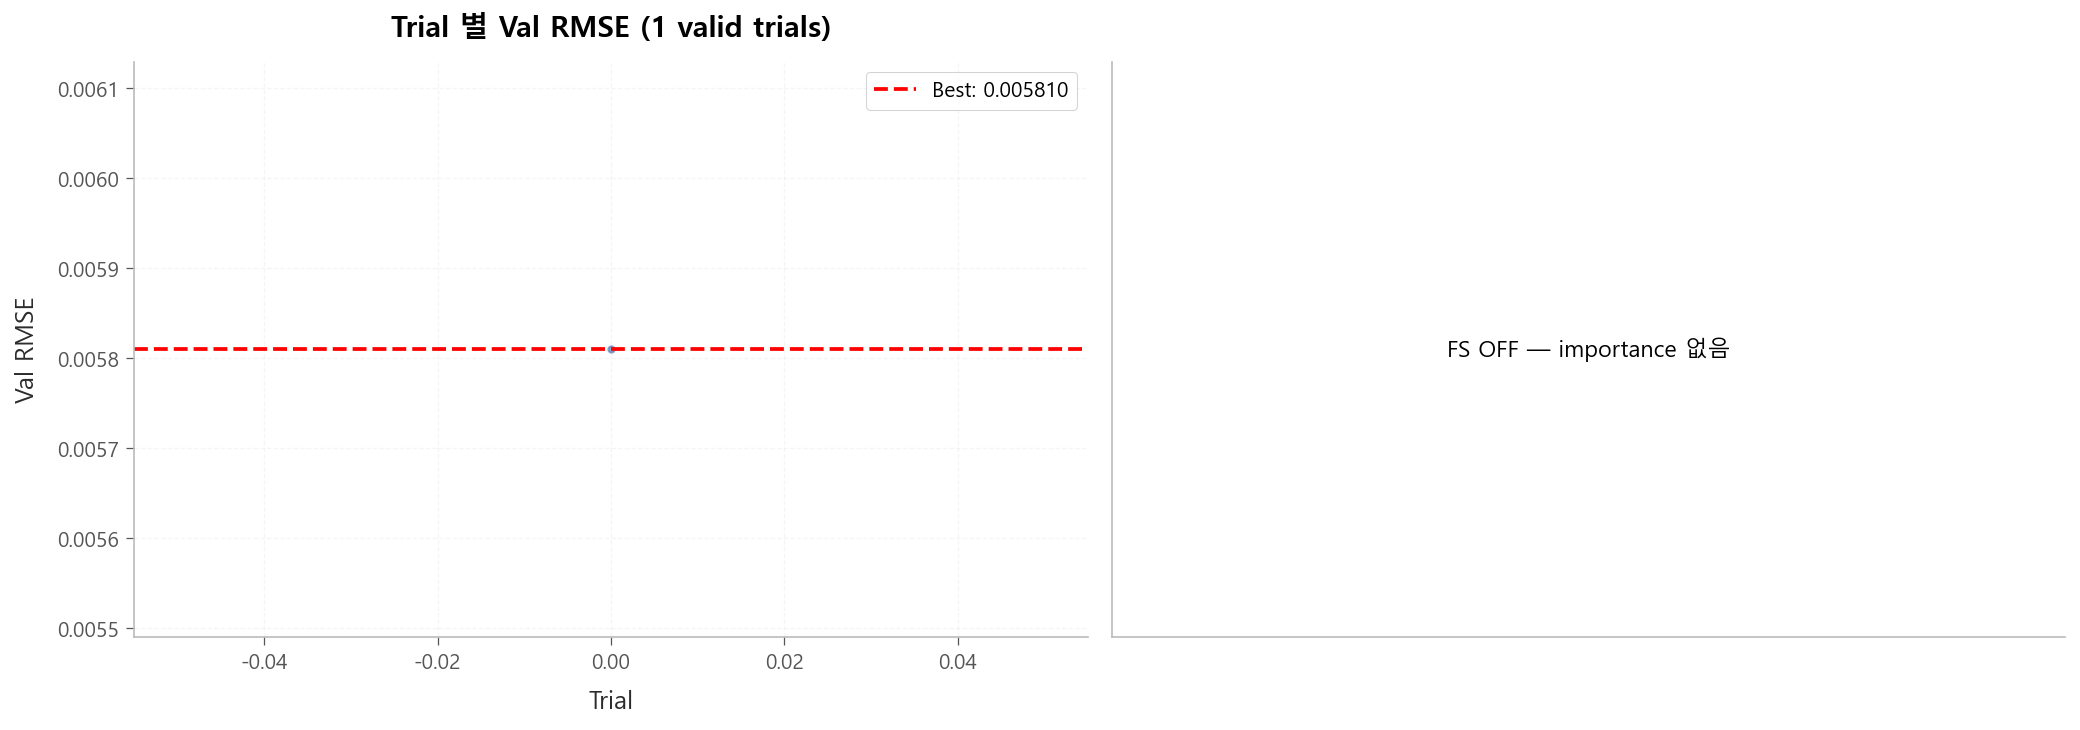

In [7]:
# --- 결과 시각화 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax_trial, ax_imp = axes[0], axes[1]

# Trial RMSE 추이
trials = study.trials
vals = [t.value for t in trials if t.value is not None and t.value < float('inf')]
ax_trial.plot(vals, 'o-', markersize=3, alpha=0.6)
ax_trial.axhline(study.best_value, color='r', linestyle='--',
                 label=f'Best: {study.best_value:.6f}')
ax_trial.set_xlabel('Trial')
ax_trial.set_ylabel('Val RMSE')
ax_trial.set_title(f'Trial 별 Val RMSE ({len(vals)} valid trials)')
ax_trial.legend()
ax_trial.grid(alpha=0.3)

# Feature importance (top 20)
if final.get('importances') is not None:
    imp_series = pd.Series(final['importances']).sort_values(ascending=True).tail(20)
    imp_series.plot(kind='barh', ax=ax_imp)
    ax_imp.set_title(f'Top 20 Features (of {len(final["selected_cols"])})')
    ax_imp.set_xlabel('Importance (gain)')
else:
    ax_imp.text(0.5, 0.5, 'FS OFF — importance 없음',
                ha='center', va='center', transform=ax_imp.transAxes)
    ax_imp.set_xticks([]); ax_imp.set_yticks([])

plt.tight_layout()
plt.show()

## 7. 최종 CSV 출력 + Study 저장

- `{EXP_ID}_final_val.csv` / `{EXP_ID}_final_test.csv` — 베스트 trial 예측
- `{EXP_ID}_study.pkl` — trial별 파라미터·val RMSE·user_attrs 전부 (사후 분석용)

In [8]:
import pickle

# ─────────────────────────────────────────────────────────
# 1) Single E2E (rerun 결과) 메트릭/예측 준비
# ─────────────────────────────────────────────────────────
single_val_rmse  = float(final['val_rmse'])
single_test_rmse = float(test_rmse_score) if test_rmse_score is not None else None
single_val_pred  = final['val_pred']
single_test_pred = final['test_pred']
single_key_val   = final['unit_data']['val'][KEY_COL].values
single_key_test  = final['unit_data']['test'][KEY_COL].values

_final_test_str = f'{single_test_rmse:.6f}' if single_test_rmse is not None else 'N/A (EVAL_TEST=False)'
print(f'★ FINAL: e2e_single (lgbm, preprocessing HPO)')
print(f'  Val RMSE : {single_val_rmse:.6f}')
print(f'  Test RMSE: {_final_test_str}')

# ─────────────────────────────────────────────────────────
# 2) CSV + Optuna study pickle 저장 (SAVE_OUTPUTS 스위치)
# ─────────────────────────────────────────────────────────
if SAVE_OUTPUTS:
    final_val_path  = os.path.join(OUTPUT_DIR, f'{EXP_ID}_final_val.csv')
    final_test_path = os.path.join(OUTPUT_DIR, f'{EXP_ID}_final_test.csv')
    pd.DataFrame({KEY_COL: single_key_val,  TARGET_COL: single_val_pred }).to_csv(final_val_path,  index=False)
    pd.DataFrame({KEY_COL: single_key_test, TARGET_COL: single_test_pred}).to_csv(final_test_path, index=False)
    print(f'  → {final_val_path}')
    print(f'  → {final_test_path}')

    study_path = os.path.join(OUTPUT_DIR, f'{EXP_ID}_study.pkl')
    with open(study_path, 'wb') as f:
        pickle.dump(study, f)
    print(f'  → {study_path}  ({len(study.trials)} trials)')
else:
    print('  [SAVE_OUTPUTS=False] CSV / study pickle 저장 생략')

★ FINAL: e2e_single (lgbm, preprocessing HPO)
  Val RMSE : 0.005810
  Test RMSE: 0.008489
  [SAVE_OUTPUTS=False] CSV / study pickle 저장 생략


## 8. 실험 로그

In [9]:
# ============================================================
# 실험 로그 — 모든 파라미터 기록 (JSON + XLSX 증분 저장)
# ============================================================
# 재현성 원칙: 이 JSON 한 개만 보고도 실험을 100% 재현할 수 있어야 함

# ── 전처리 search space 덤프 (후보 list 그대로) ──
preprocessing_search_space_dump = {
    'PP_CLEAN_CANDIDATES':   {k: list(v) for k, v in PP_CLEAN_CANDIDATES.items()},
    'PP_OUTLIER_CANDIDATES': {k: list(v) for k, v in PP_OUTLIER_CANDIDATES.items()},
    'AGG_PRESETS':           [list(p) for p in AGG_PRESETS],
}

# ── 베스트 전처리 파라미터 (재현 가능성 보장) ──
best_pp_params  = final['best_pp_params']
best_cleaning   = final['cleaning_args']
best_outlier    = final['outlier_args']
best_agg_funcs  = final['agg_funcs']

log_experiment(
    exp_id=EXP_ID,
    exp_type=EXP_TYPE,
    best_model=f'e2e_single ({e2e_params["reg_model"]})',
    val_rmse=single_val_rmse,
    test_rmse=single_test_rmse,
    n_features=len(final['selected_cols']),
    memo=EXP_MEMO,
    cleaning_params=best_cleaning,
    outlier_params=best_outlier,
    feature_sel_params={
        'method': 'e2e_top_k' if pipeline_config['run_fs'] else 'none',
        'top_k': best_params.get('top_k'),
        'top_k_fixed': e2e_params['top_k_fixed'],
        'top_k_range': e2e_params['top_k_range'],
    },
    agg_params={
        'agg_funcs': best_agg_funcs,
    },
    model_params={
        'pipeline': 'E2E Joint HPO (preprocessing + lgbm)',
        # ── 전체 설정 dict (재현용) ──
        'pipeline_config': pipeline_config,
        'e2e_params': e2e_params,
        'rerun_params': rerun_params,
        'sampling_params': sampling_params,
        'label_col': LABEL_COL,
        'exclude_cols': EXCLUDE_COLS,
        # ── 전처리 HPO 탐색 공간 + 베스트 ──
        'preprocessing_search_space': preprocessing_search_space_dump,
        'best_preprocessing_params': best_pp_params,
        # ── 베스트 하이퍼파라미터 ──
        'best_params': best_params,
        'best_val_rmse_hpo': result['best_value'],
        'best_val_rmse_rerun': final['val_rmse'],
        'best_test_rmse_rerun': test_rmse_score,
        # ── 최종 선정 ──
        'final_method': 'e2e_single',
        'final_val_rmse': single_val_rmse,
        'final_test_rmse': single_test_rmse,
    },
    feature_cols=final['selected_cols'],
    xlsx_gdrive_id=XLSX_GDRIVE_ID,
    json_gdrive_id=JSON_GDRIVE_ID,
)


실험 기록 완료: 3-3-005
  타입: E2E LGBM Baseline (pp+hp joint HPO) | 베스트: e2e_single (lgbm)
  Val RMSE:  0.005810  (+0.000007)
  Test RMSE: 0.008489
  피처수: 749 | 메모: lgbm-only, preprocessing+hp joint optuna
  xlsx: c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\experiments.xlsx
  json: c:\Users\Dell5371\Desktop\기업연계프로젝트\4_output\experiments\experiments.json
